# 03 — EDA: Customer-Level Features

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_SEED = 42
DATA_DIR = Path('..') / 'data' / 'raw'

pd.set_option('display.max_columns', 100)


## 1. Load Processed Data

In [14]:
PROCESSED_DIR = Path('..') / 'data' / 'processed'
customers = pd.read_csv(PROCESSED_DIR / 'customers.csv', index_col='customer_id')
customers['earliest_transaction_date'] = pd.to_datetime(customers['earliest_transaction_date'])
customers['latest_transaction_date']   = pd.to_datetime(customers['latest_transaction_date'])
print(customers.shape)
customers.head()


(49661, 29)


,earliest_transaction_date,latest_transaction_date,n_transactions,unique_product_categories,avg_amount_spent,std_amount_spent,total_returns,n_payment_methods_used,female,customer_age,churn,days_since_last_purchase,customer_tenure_days,return_rate,purchase_frequency,prct_paid_cash,prct_paid_credit_card,prct_paid_paypal,prct_txn_Books,prct_txn_Clothing,prct_txn_Electronics,prct_txn_Home,prct_spend_books,prct_spend_clothing,prct_spend_electronics,prct_spend_home,avg_days_between_transactions,std_days_between_transactions,spend_trend
customer_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2020-03-04 10:26:02,2022-11-29 06:48:25,3,3,1866.666667,728.943299,0.0,2,1,67,0,288,999,0.000000,0.003003,0.333333,0.666667,0.00,0.333333,0.333333,0.333333,0.000000,0.407143,0.183036,0.409821,0.000000,499.500000,140.714249,635.000000
2,2020-07-31 16:27:41,2023-07-03 17:26:19,6,4,1076.500000,733.490763,4.0,3,1,42,0,72,1067,0.666667,0.005623,0.333333,0.166667,0.50,0.166667,0.166667,0.500000,0.166667,0.029416,0.113950,0.623781,0.232853,212.800000,118.480800,28.028571
3,2020-01-19 00:03:00,2023-02-03 03:58:07,4,3,903.250000,930.772931,0.0,3,0,31,0,222,1111,0.000000,0.003600,0.250000,0.500000,0.25,0.000000,0.250000,0.500000,0.250000,0.000000,0.039856,0.781622,0.178522,369.666667,243.643866,-558.900000
4,2020-10-12 22:03:10,2022-06-29 03:41:09,5,4,867.800000,673.754184,3.0,3,0,37,0,441,624,0.600000,0.008013,0.400000,0.200000,0.40,0.400000,0.200000,0.200000,0.200000,0.314358,0.377967,0.053238,0.254437,155.500000,51.630095,-64.300000
5,2020-04-08 21:57:19,2022-07-16 04:08:09,5,2,452.600000,314.805178,3.0,3,1,24,0,424,828,0.600000,0.006039,0.200000,0.400000,0.40,0.400000,0.000000,0.000000,0.600000,0.457357,0.000000,0.000000,0.542643,206.500000,165.098960,60.600000


## 2. Correlation Heatmap

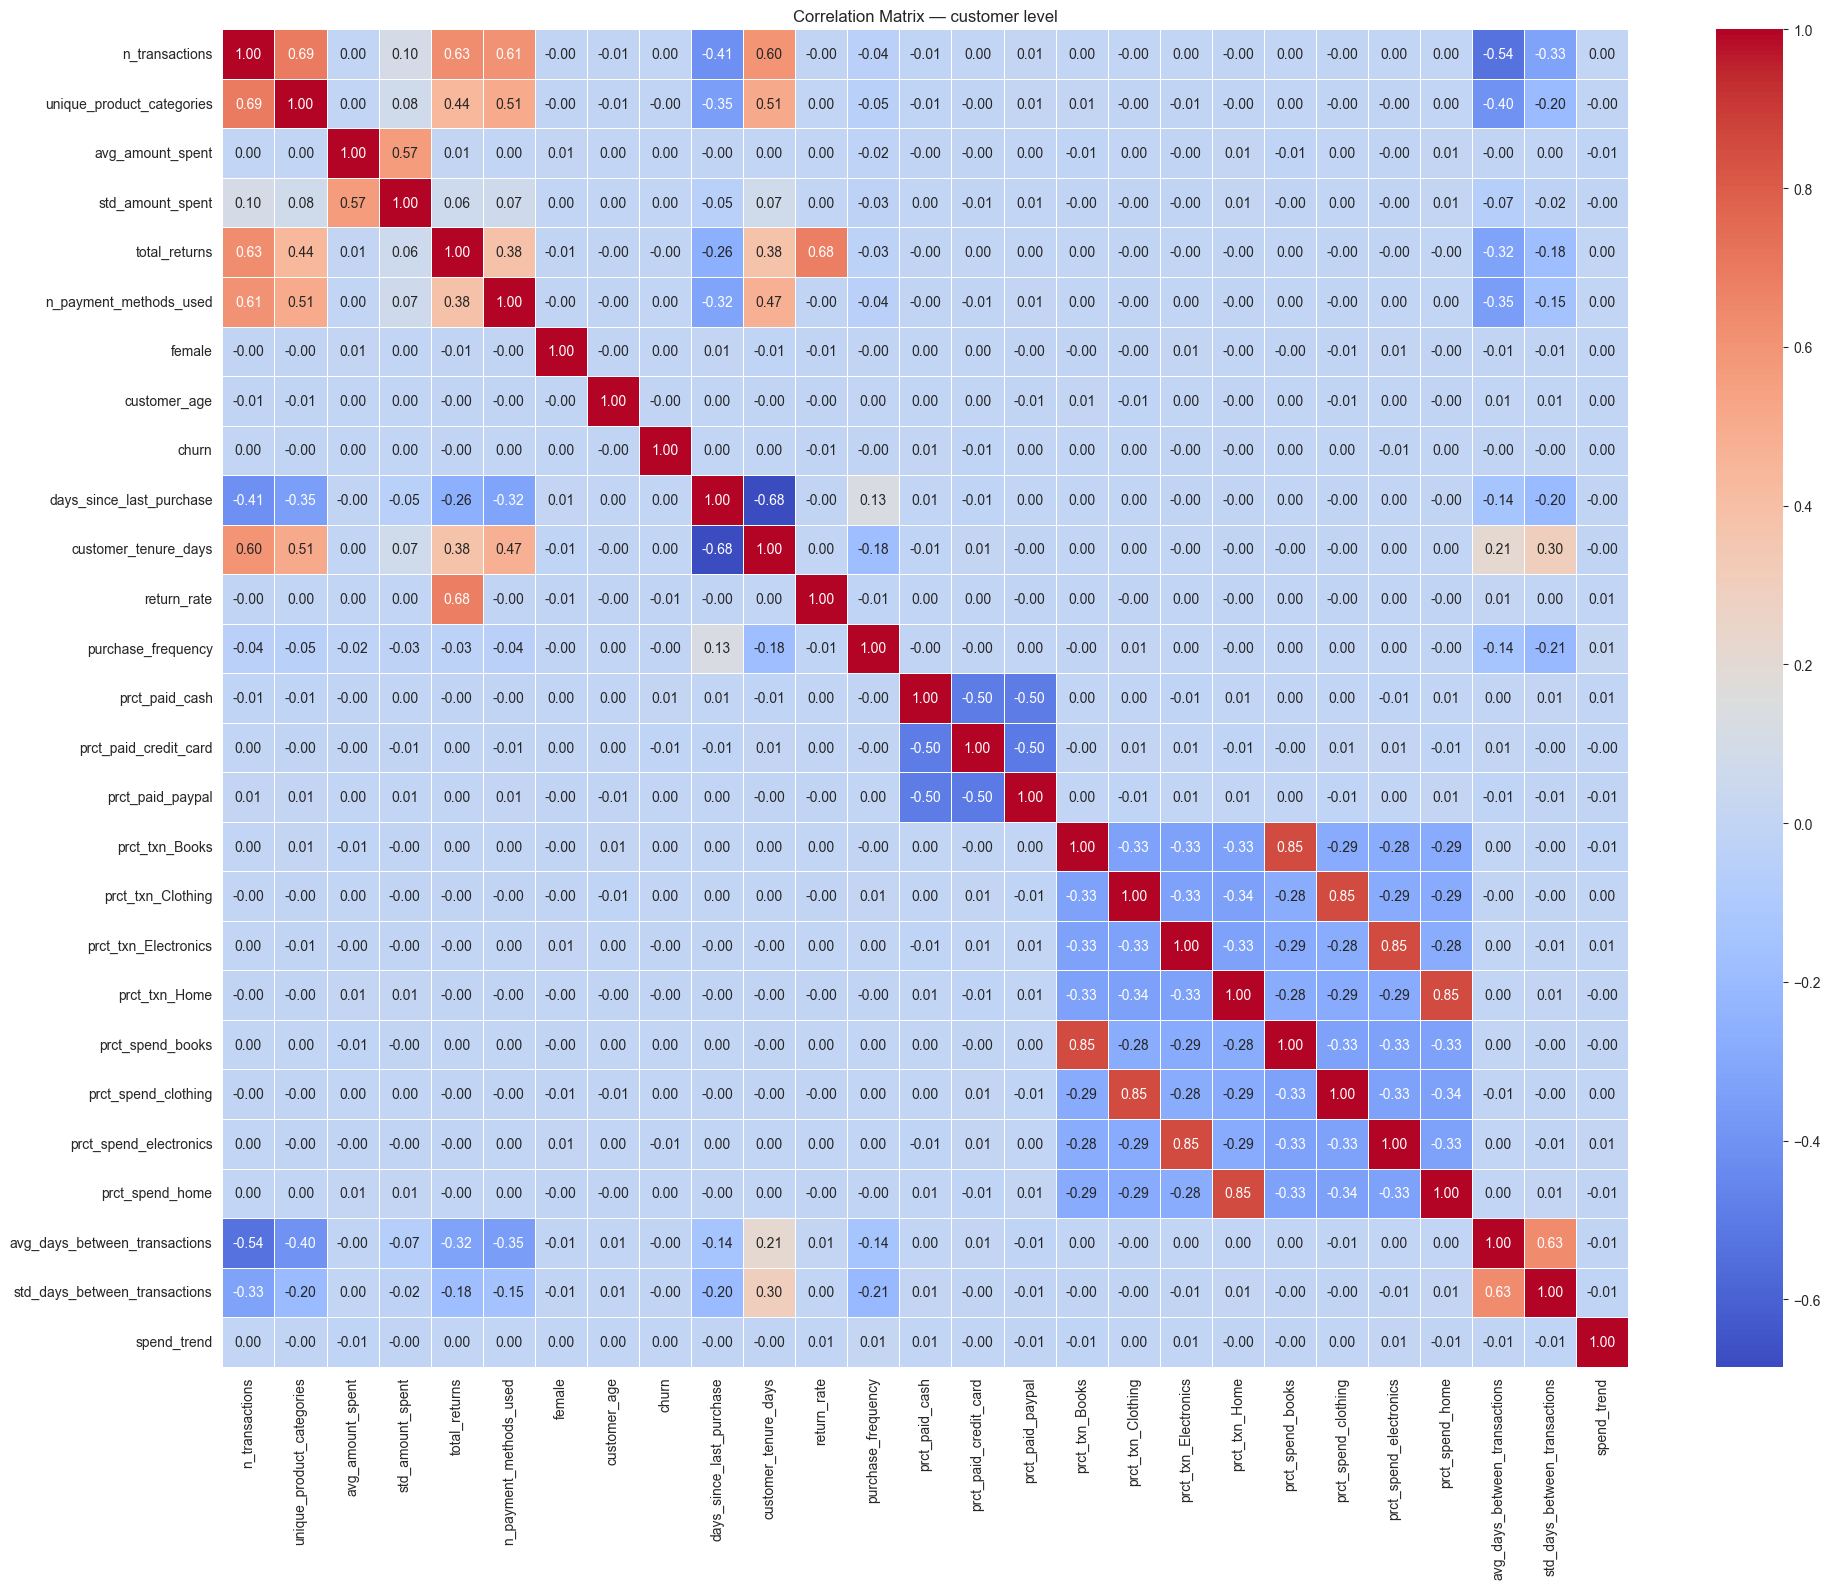

In [15]:
exclude_cols = ['earliest_transaction_date', 'latest_transaction_date']
cust_num = customers.drop(columns=exclude_cols).select_dtypes(include=np.number)

plt.figure(figsize=(20, 16))
sns.heatmap(cust_num.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix — customer level')
plt.tight_layout()
plt.show()


## 3. Feature Distributions vs Churn

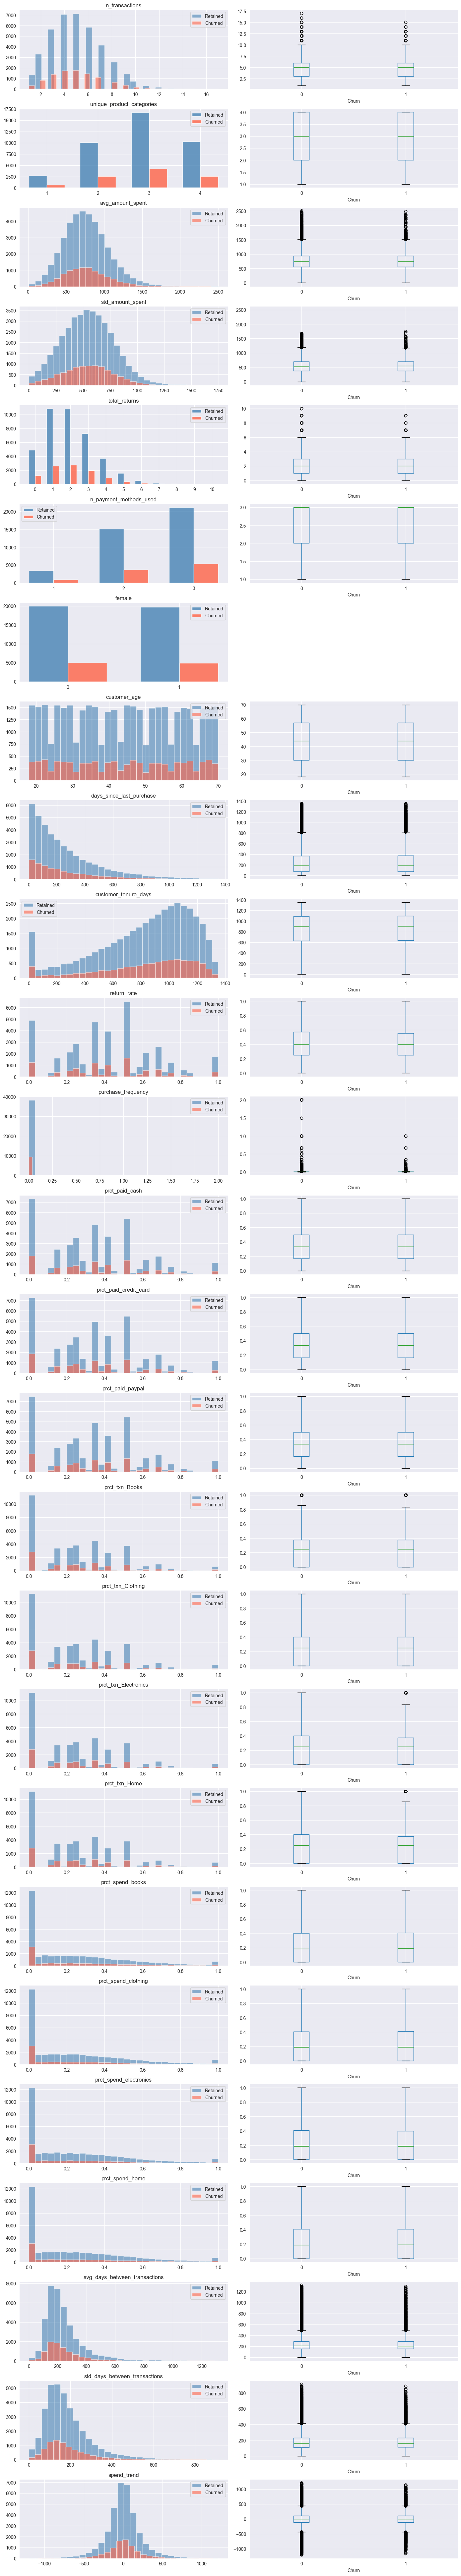

In [16]:
target_col    = 'churn'
exclude       = ['earliest_transaction_date', 'latest_transaction_date', target_col]
feat_cols     = [c for c in customers.columns if c not in exclude]

# Discrete columns — bar chart with integer x-axis, no continuous bins
DISCRETE_COLS = {'n_payment_methods_used', 'female', 'total_returns', 'unique_product_categories'}

# Binary columns — bar chart only, no boxplot
NO_BOXPLOT_COLS = {'female'}

# Columns whose boxplots share the same y-axis
SHARED_YAXIS = [['avg_amount_spent', 'std_amount_spent']]

def shared_ylim(cols):
    vals = customers[cols].values.flatten()
    vals = vals[~np.isnan(vals)]
    pad  = (vals.max() - vals.min()) * 0.05
    return vals.min() - pad, vals.max() + pad

shared_limits = {}
for group in SHARED_YAXIS:
    lim = shared_ylim(group)
    for c in group:
        shared_limits[c] = lim

fig, axes = plt.subplots(len(feat_cols), 2, figsize=(14, len(feat_cols) * 3))

for i, col in enumerate(feat_cols):
    ax_hist, ax_box = axes[i, 0], axes[i, 1]

    if col in DISCRETE_COLS:
        vals = sorted(customers[col].dropna().unique())
        x, w = np.arange(len(vals)), 0.35
        for j, (churn_val, label, color) in enumerate([(0,'Retained','steelblue'), (1,'Churned','tomato')]):
            counts = [customers[customers[target_col] == churn_val][col].value_counts().get(v, 0) for v in vals]
            ax_hist.bar(x + j * w, counts, width=w, label=label, color=color, alpha=0.8)
        ax_hist.set_xticks(x + w / 2)
        ax_hist.set_xticklabels([int(v) for v in vals])
    else:
        for churn_val, label, color in [(0,'Retained','steelblue'), (1,'Churned','tomato')]:
            subset = customers[customers[target_col] == churn_val][col].dropna()
            ax_hist.hist(subset, bins=30, alpha=0.6, label=label, color=color)

    ax_hist.set_title(col)
    ax_hist.legend()

    if col in NO_BOXPLOT_COLS:
        ax_box.set_visible(False)
    else:
        customers.boxplot(column=col, by=target_col, ax=ax_box)
        ax_box.set_title('')
        ax_box.set_xlabel('Churn')
        if col in shared_limits:
            ax_box.set_ylim(shared_limits[col])

plt.suptitle('')
plt.tight_layout()
plt.show()


## 4. Temporal Analysis

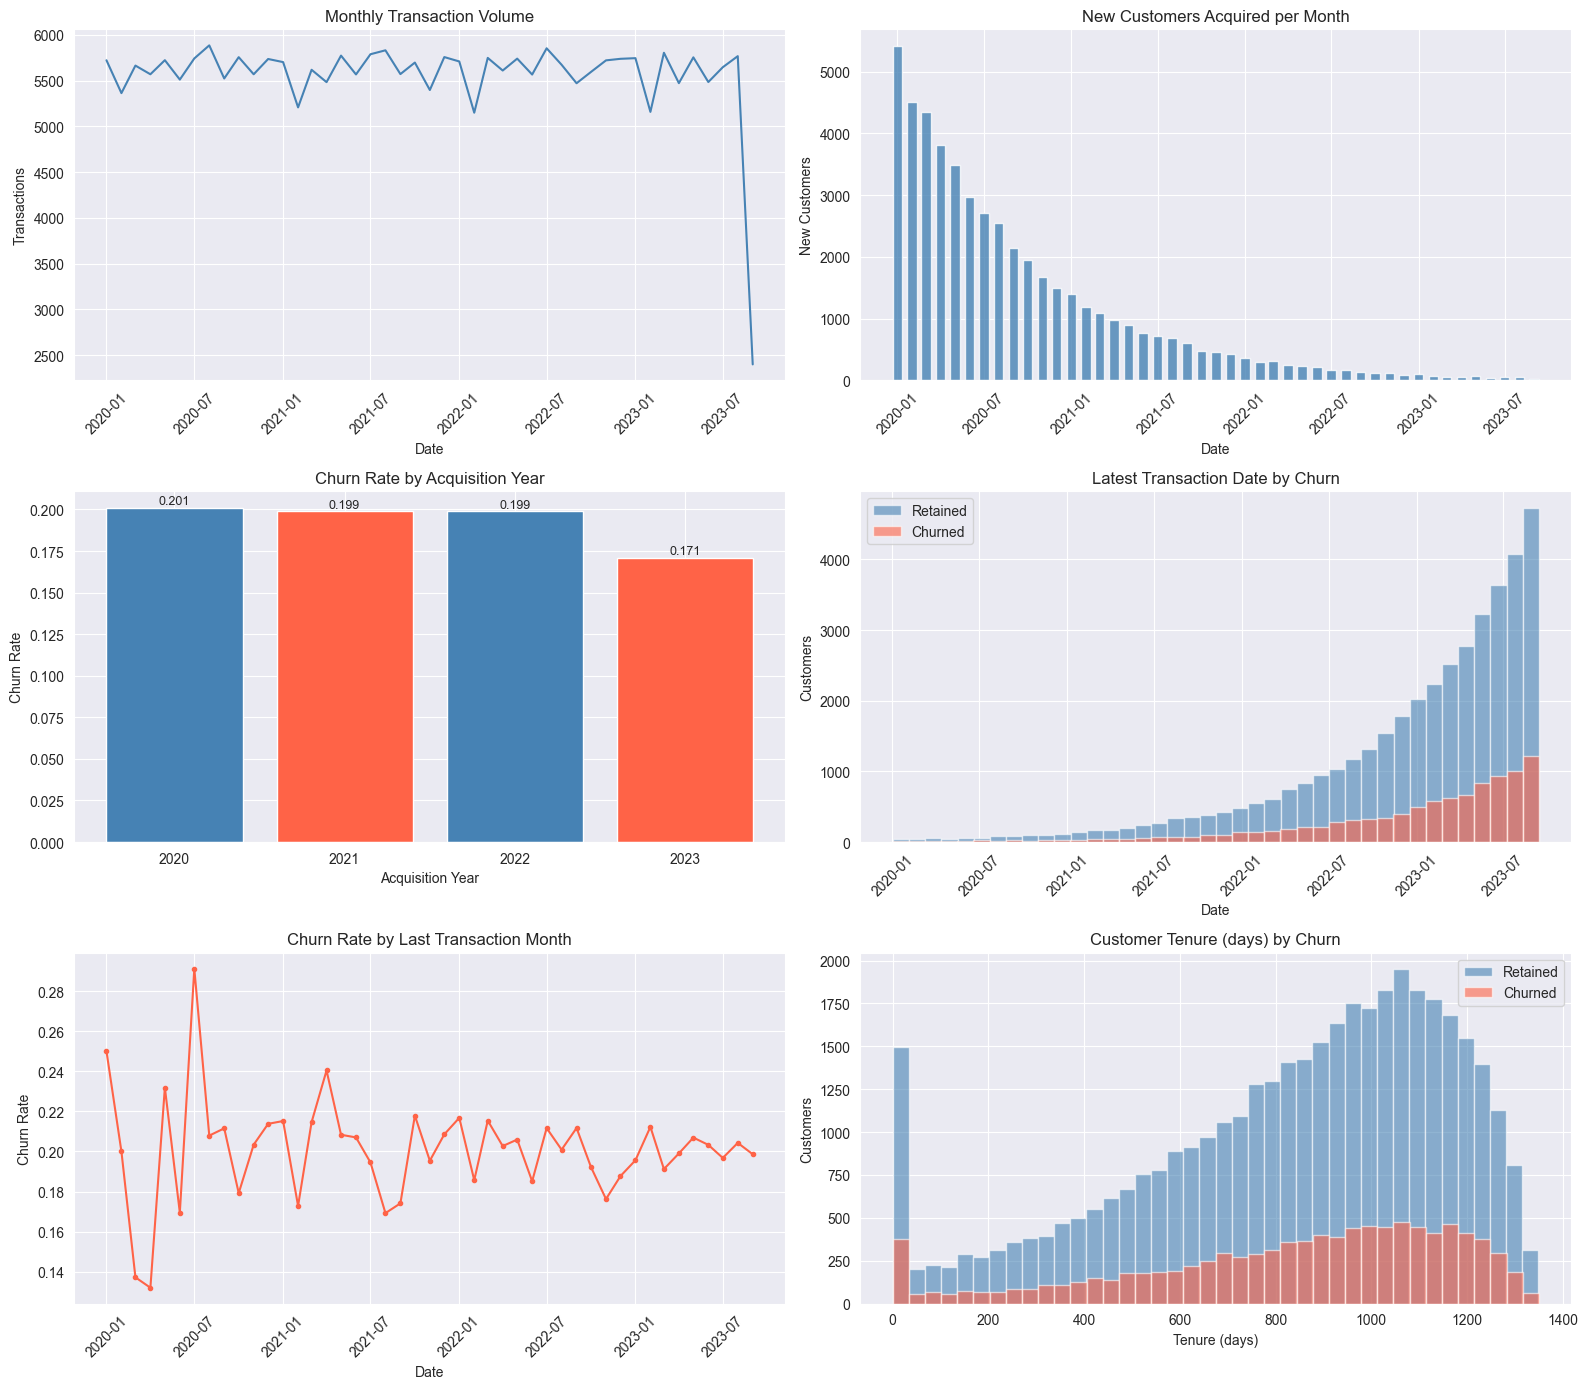

Transaction date range  : 2020-01-01 → 2023-09-13
Peak transaction month  : 2020-08 (5,886 txns)
Lowest transaction month: 2023-09 (2,399 txns)

Churn rate by acquisition year:
acquisition_year
2020    0.201
2021    0.199
2022    0.199
2023    0.171


In [17]:
RAW_DIR = Path('..') / 'data' / 'raw'
txn = pd.read_csv(RAW_DIR / 'ecommerce_customer_data_large.csv')
txn.columns = txn.columns.str.lower().str.replace(' ', '_')
txn['purchase_date'] = pd.to_datetime(txn['purchase_date'])
txn['year_month']    = txn['purchase_date'].dt.to_period('M')

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# ── 1. Monthly transaction volume ────────────────────────────────────────────
monthly_vol = txn.groupby('year_month').size()
monthly_vol.index = monthly_vol.index.to_timestamp()
axes[0, 0].plot(monthly_vol.index, monthly_vol.values, color='steelblue')
axes[0, 0].set_title('Monthly Transaction Volume')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Transactions')
axes[0, 0].tick_params(axis='x', rotation=45)

# ── 2. New customers acquired per month ──────────────────────────────────────
first_purchase = txn.groupby('customer_id')['purchase_date'].min().dt.to_period('M')
new_customers  = first_purchase.value_counts().sort_index()
new_customers.index = new_customers.index.to_timestamp()
axes[0, 1].bar(new_customers.index, new_customers.values, width=20, color='steelblue', alpha=0.8)
axes[0, 1].set_title('New Customers Acquired per Month')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('New Customers')
axes[0, 1].tick_params(axis='x', rotation=45)

# ── 3. Churn rate by acquisition year (cohort) ───────────────────────────────
customers['acquisition_year'] = customers['earliest_transaction_date'].dt.year
cohort_churn = customers.groupby('acquisition_year')['churn'].mean().round(3)
axes[1, 0].bar(cohort_churn.index.astype(str), cohort_churn.values, color=['steelblue','tomato','steelblue','tomato'])
axes[1, 0].set_title('Churn Rate by Acquisition Year')
axes[1, 0].set_xlabel('Acquisition Year')
axes[1, 0].set_ylabel('Churn Rate')
for x, v in zip(cohort_churn.index.astype(str), cohort_churn.values):
    axes[1, 0].text(x, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)

# ── 4. Distribution of latest transaction date by churn ──────────────────────
for churn_val, label, color in [(0,'Retained','steelblue'), (1,'Churned','tomato')]:
    subset = customers[customers['churn'] == churn_val]['latest_transaction_date']
    axes[1, 1].hist(subset, bins=40, alpha=0.6, label=label, color=color)
axes[1, 1].set_title('Latest Transaction Date by Churn')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Customers')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=45)

# ── 5. Monthly churn rate (based on latest transaction month) ─────────────────
customers['last_txn_month'] = customers['latest_transaction_date'].dt.to_period('M')
monthly_churn = customers.groupby('last_txn_month')['churn'].mean()
monthly_churn.index = monthly_churn.index.to_timestamp()
axes[2, 0].plot(monthly_churn.index, monthly_churn.values, color='tomato', marker='o', markersize=3)
axes[2, 0].set_title('Churn Rate by Last Transaction Month')
axes[2, 0].set_xlabel('Date')
axes[2, 0].set_ylabel('Churn Rate')
axes[2, 0].tick_params(axis='x', rotation=45)

# ── 6. Customer tenure distribution by churn ─────────────────────────────────
for churn_val, label, color in [(0,'Retained','steelblue'), (1,'Churned','tomato')]:
    subset = customers[customers['churn'] == churn_val]['customer_tenure_days'].dropna()
    axes[2, 1].hist(subset, bins=40, alpha=0.6, label=label, color=color)
axes[2, 1].set_title('Customer Tenure (days) by Churn')
axes[2, 1].set_xlabel('Tenure (days)')
axes[2, 1].set_ylabel('Customers')
axes[2, 1].legend()

plt.tight_layout()
plt.show()

# Summary stats
print('Transaction date range  :', txn['purchase_date'].min().date(), '→', txn['purchase_date'].max().date())
print('Peak transaction month  :', monthly_vol.idxmax().strftime('%Y-%m'), f'({monthly_vol.max():,} txns)')
print('Lowest transaction month:', monthly_vol.idxmin().strftime('%Y-%m'), f'({monthly_vol.min():,} txns)')
print('\nChurn rate by acquisition year:')
print(cohort_churn.to_string())
